<a href="https://colab.research.google.com/github/ethereins/2311532016_IndahSyahfitri_ImageProcessing/blob/main/IPTugas3_IndahSyahfitri_2311532016.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving pria sawit itu lagi.jfif to pria sawit itu lagi.jfif


Kode di atas ini berfungsi untuk mengimpor modul files yang tersedia di Google Colab dan digunakan untuk menangani proses unggah atau unduh file. Jadi saat dirun, kita bisa memilih foto yang akan diproses.

(np.float64(-0.5), np.float64(735.5), np.float64(735.5), np.float64(-0.5))

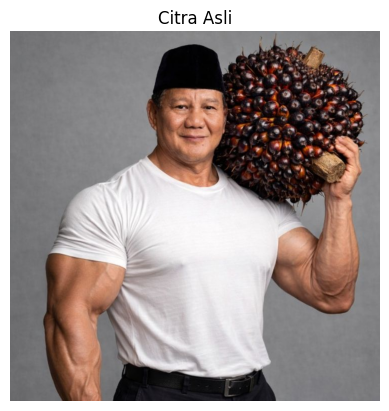

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('pria sawit itu lagi.jfif')

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Citra Asli")
plt.axis('off')

Kode tersebut digunakan untuk membaca dan menampilkan citra asli. Library cv2 digunakan untuk membaca citra, numpy untuk operasi array, dan matplotlib untuk menampilkan gambar. Perintah cv2.imread('prabski.jpeg') membaca file citra, kemudian cv2.cvtColor(img, cv2.COLOR_BGR2RGB) mengubah format warna dari BGR ke RGB agar tampil dengan benar saat ditampilkan menggunakan plt.imshow(). Judul gambar ditambahkan dengan plt.title("Citra Asli"), dan plt.axis('off') digunakan untuk menyembunyikan sumbu pada tampilan citra.

(np.float64(-0.5), np.float64(735.5), np.float64(735.5), np.float64(-0.5))

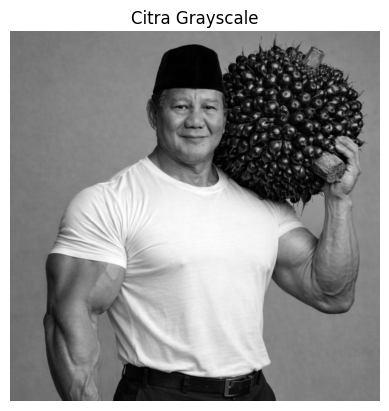

In [3]:
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
M, N = img_gray.shape

result = np.zeros((M,N), dtype=np.uint8)

for i in range(M):
    for j in range(N):
        value = int(img_gray[i,j])

        if value > 255:
            value = 255
        elif value < 0:
            value = 0

        result[i,j] = value

plt.imshow(img_gray, cmap='gray')
plt.title("Citra Grayscale")
plt.axis('off')

Kode tersebut digunakan untuk mengubah citra menjadi grayscale dan menampilkannya. Perintah cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) mengubah citra berwarna menjadi citra grayscale dan disimpan dalam variabel img_gray. Kemudian ukuran citra diambil dengan M, N = img_gray.shape. Array kosong result dibuat dengan ukuran yang sama untuk menyimpan nilai piksel. Melalui perulangan for, setiap piksel diambil nilainya lalu dicek agar tetap berada pada rentang 0–255.

In [4]:
import numpy as np

Library NumPy digunakan dalam program ini untuk mengolah data numerik dalam bentuk matriks atau array. Dalam pengolahan citra digital, gambar direpresentasikan sebagai matriks yang berisi nilai intensitas piksel, sehingga NumPy membantu mempermudah proses perhitungan dan manipulasi data dalam bentuk array.

In [5]:
kernel = np.ones((5,5)) / 25
height, width = img_gray.shape
pad = 2

Lanjut ke proses, pertama-tama kita buat kernel rataan berukuran 5×5 menggunakan np.ones((5,5)) / 25. Fungsi np.ones((5,5)) menghasilkan matriks berisi angka 1 dengan ukuran 5×5, kemudian setiap nilai dibagi 25 agar menghasilkan nilai rata-rata dari 25 piksel pada area kernel. Kernel ini digunakan untuk melakukan proses smoothing atau perataan pada citra. Selanjutnya, height, width = img_gray.shape digunakan untuk mengambil ukuran citra grayscale, yaitu tinggi (height) dan lebar (width) citra. Terakhir, pad = 2 digunakan untuk menentukan jumlah padding di tepi citra, sehingga proses konvolusi dengan kernel 5×5 dapat dilakukan hingga bagian tepi citra.

In [7]:
padded = np.pad(img_gray, ((pad,pad),(pad,pad)), mode='constant')
output = np.zeros((height, width))

Selanjutnya, kita bisa menyiapkan citra agar proses konvolusi dapat dilakukan dengan benar. Perintah padded = np.pad(img_gray, ((pad,pad),(pad,pad)), mode='constant') digunakan untuk menambahkan padding di sekeliling citra grayscale. Padding ini berupa penambahan baris dan kolom di bagian tepi citra dengan nilai konstan (biasanya bernilai 0). Tujuan dari padding adalah agar proses konvolusi dengan kernel berukuran 5×5 tetap dapat dilakukan hingga bagian tepi citra tanpa mengurangi ukuran hasil akhir. Selanjutnya, output = np.zeros((height, width)) digunakan untuk membuat matriks baru yang berisi nilai nol dengan ukuran yang sama seperti citra asli. Matriks ini berfungsi sebagai tempat untuk menyimpan hasil perhitungan konvolusi yang akan dihasilkan dari proses filtering pada citra.

In [8]:
for i in range(height):
    for j in range(width):

        total = 0

        for m in range(5):
            for n in range(5):
                total += padded[i+m][j+n] * kernel[m][n]

        output[i][j] = total

print("Konvolusi selesai")

Konvolusi selesai


Kode di atas adalah bagian utama dari proses konvolusi pada citra. Perulangan for i in range(height) dan for j in range(width) digunakan untuk mengakses setiap piksel pada citra. Pada setiap posisi piksel, variabel total diinisialisasi dengan nilai 0 untuk menampung hasil perhitungan sementara. Selanjutnya dilakukan perulangan for m in range(5) dan for n in range(5) untuk mengambil area piksel berukuran 5×5 dari citra yang sudah diberi padding. Nilai piksel pada area tersebut kemudian dikalikan dengan nilai kernel yang bersesuaian, dan hasilnya dijumlahkan ke dalam variabel total. Setelah seluruh elemen kernel selesai diproses, nilai total disimpan ke dalam matriks output[i][j] sebagai nilai piksel baru pada citra hasil konvolusi. Jika proses konvolusi telah berhasil dan selesai dijalankan, muncul output "Konvolusi Selesai."

(np.float64(-0.5), np.float64(735.5), np.float64(735.5), np.float64(-0.5))

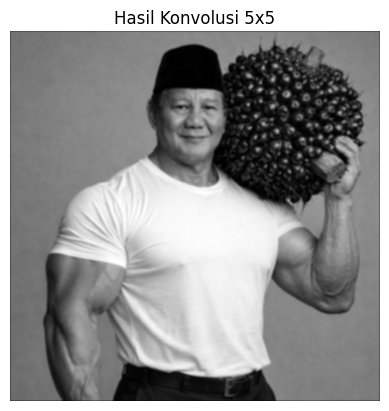

In [9]:
import matplotlib.pyplot as plt

plt.imshow(output, cmap='gray')
plt.title("Hasil Konvolusi 5x5")
plt.axis('off')

Dengan library matplotlib.pyplot di atas, kita bisa menampilkan citra hasil dari proses konvolusi yang sudah dilakukan. Untuk melihat perbandingannya secara langsung, kita dapat mengetikkan kode di bawah ini.

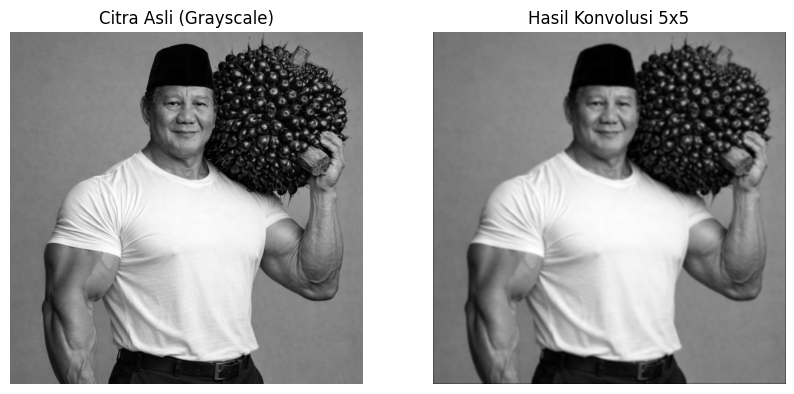

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# Citra asli
plt.subplot(1,2,1)
plt.imshow(img_gray, cmap='gray') # Menambahkan cmap='gray' untuk menampilkan citra grayscale dengan benar
plt.title("Citra Asli (Grayscale)")
plt.axis('off')

# Citra hasil konvolusi
plt.subplot(1,2,2)
plt.imshow(output, cmap='gray')
plt.title("Hasil Konvolusi 5x5")
plt.axis('off')

plt.show()

Berdasarkan hasil yang ditampilkan pada gambar, proses konvolusi menggunakan kernel rataan berukuran 5×5 menghasilkan citra yang tampak lebih halus dibandingkan citra grayscale asli. Pada citra asli, detail tekstur seperti pola pada buah kelapa sawit, lipatan pada pakaian, serta garis-garis pada otot lengan masih terlihat cukup tajam. **Setelah dilakukan proses konvolusi, citra mengalami efek smoothing atau perataan intensitas piksel, sehingga beberapa detail kecil pada gambar menjadi sedikit lebih lembut.** Hal ini terjadi karena setiap piksel pada citra hasil tidak lagi hanya berasal dari nilai piksel tunggal, tetapi merupakan hasil rata-rata dari 25 piksel tetangga dalam area kernel 5×5 yang dihitung selama proses konvolusi.

Efek smoothing tersebut juga menyebabkan perubahan pada ketajaman tepi objek. Pada citra hasil konvolusi, batas antara objek utama dan latar belakang masih terlihat jelas, namun tidak setajam pada citra asli. Misalnya pada bagian tepi tubuh, topi, serta kontur buah kelapa sawit yang terlihat sedikit lebih kabur. Meskipun demikian, bentuk dan struktur objek pada citra tetap dapat dikenali dengan baik. Proses ini menunjukkan bahwa kernel rataan bekerja dengan cara mengurangi variasi intensitas yang terlalu tajam antar piksel, sehingga perubahan intensitas menjadi lebih bertahap.

Selain itu, proses konvolusi juga membantu mengurangi noise atau gangguan kecil pada citra. Dengan menghitung nilai rata-rata dari piksel-piksel di sekitarnya, nilai piksel yang terlalu tinggi atau terlalu rendah akan disesuaikan dengan nilai tetangganya. Akibatnya, citra hasil terlihat lebih stabil dan tidak terlalu memiliki perbedaan kontras yang ekstrem pada area-area kecil. Secara keseluruhan, hasil konvolusi menggunakan kernel 5×5 berhasil menghasilkan citra yang lebih halus dan lebih seragam dalam distribusi intensitasnya, meskipun dengan konsekuensi berkurangnya ketajaman detail pada beberapa bagian gambar.